<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/12.%20Cross-Validation%20and%20Model%20Evaluation%20/%20Ch12_Cross_Validation_and_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Cross-Validation and Model Evaluation Techniques

A well-known British statistician, George Box, is famous for saying that *"All [statistical] models are wrong, but some are useful."* As machine learning practitioners, this is valuable to keep in mind because it reminds us that no matter how much we train a model or fine-tune its hyperparameters, there will always be instances where it makes a wrong prediction, the underlying data distribution changes, or any number of potential events that can make our model work less effectively.

This chapter explores **advanced cross-validation methods**, **model evaluation metrics**, and **techniques for selecting the best models**. We move beyond the naive single train-test split and learn to rigorously estimate how our models will perform in production -- where the data is unseen, potentially shifted, and unforgiving.

**What we will cover:**

1. Introduction to cross-validation (k-fold and stratified k-fold)
2. Advanced cross-validation methods (LOOCV and nested CV)
3. Implementing cross-validation with scikit-learn's high-level API
4. Model selection techniques (grid search vs. randomized search)
5. Evaluating model generalizability (learning curves and validation curves)

## Setup

We begin by importing the core libraries used throughout this chapter. All code is compatible with Google Colab's default environment -- no additional `pip install` commands are needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print(f"NumPy version: {np.__version__}")
print("Setup complete.")

NumPy version: 2.0.2
Setup complete.


## 12.1 Introduction to Cross-Validation

Cross-validation is a cornerstone technique for assessing how an ML model will perform on unseen data. Instead of relying on a single train-test split -- where our performance estimate depends heavily on *which* samples happened to land in each set -- we divide the dataset into multiple subsets, training and validating the model several times to obtain a more reliable estimate of its **generalization ability**.

The fundamental idea is simple: if a model performs well across many different train-test configurations, we can be more confident that it has learned genuine patterns rather than memorizing artifacts of one particular split.

### k-Fold Cross-Validation

In **k-fold cross-validation**, the dataset is partitioned into $k$ equally sized subsets ("folds"). The model is trained $k$ times, each time using $k - 1$ folds for training and the remaining fold for validation. The final performance estimate is the average across all $k$ evaluations:

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score}_i$$

where $\text{Score}_i$ is the evaluation metric (e.g., accuracy) on fold $i$. The **standard deviation** across folds gives us a measure of how sensitive the model is to the particular data split -- high variance signals instability.

### Stratified k-Fold Cross-Validation

Standard k-fold makes no guarantees about class balance within each fold. **Stratified k-fold** preserves the percentage of samples for each class in every fold, ensuring that each fold is a representative miniature of the full dataset. This is especially important for **imbalanced classification** problems where a random fold might, by chance, contain very few samples of the minority class.

### Creating the Dataset

We generate a synthetic binary classification dataset with $500$ samples and $10$ features using `make_classification`. Of the 10 features, 8 are informative and 2 are redundant linear combinations -- a setup that gives logistic regression a reasonable but imperfect signal to learn from.

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=500, n_features=10, n_informative=8,
    n_redundant=2, n_classes=2, random_state=2024
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: X=(500, 10), y=(500,)
Class distribution: [250 250]


The dataset is perfectly balanced with $250$ samples in each class. Even in this balanced scenario, we will see that stratified k-fold provides a meaningful advantage -- it enforces that *every* fold sees this 50/50 ratio, whereas standard k-fold leaves it to chance.

### Standard k-Fold Cross-Validation

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

accuracies = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

print(f"Per-fold accuracies: {[f'{a:.3f}' for a in accuracies]}")
print(f"Average accuracy (KFold): {np.mean(accuracies):.3f}")
print(f"Std deviation (KFold): {np.std(accuracies):.3f}")

Per-fold accuracies: ['0.720', '0.720', '0.880', '0.710', '0.750']
Average accuracy (KFold): 0.756
Std deviation (KFold): 0.063


Standard 5-fold cross-validation yields a mean accuracy of **0.756** with a standard deviation of **0.063**. Two aspects of this result are worth noting.

First, the per-fold accuracies range from **0.710** to **0.880** -- a spread of $0.170$ (17 percentage points). This high variability tells us that model performance is quite sensitive to which samples end up in each fold. One fold (fold 3 at 0.880) is dramatically better than the others, likely because it happened to receive an "easier" test set where the classes were more separable.

Second, the standard deviation of **0.063** quantifies this instability. In a production context, a standard deviation this large relative to the mean ($0.063 / 0.756 \approx 8.3\%$ coefficient of variation) would make us uncomfortable quoting a single accuracy number to stakeholders. We would want to report the full range: "accuracy between 71% and 88%, averaging 76%."

Mathematically, each fold uses $400$ training samples and $100$ test samples. The accuracy on fold $i$ is:

$$\text{Acc}_i = \frac{\text{Number of correct predictions on fold } i}{100}$$

The 17-point swing between folds tells us that somewhere between $71$ and $88$ out of $100$ test samples are classified correctly depending on the split -- substantial variation for a model we might deploy.

### Stratified k-Fold Cross-Validation

In [4]:
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

strat_accuracies = []
for train_index, test_index in strat_kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    strat_accuracies.append(accuracy_score(y_test, y_pred))

print(f"Per-fold accuracies: {[f'{a:.3f}' for a in strat_accuracies]}")
print(f"Average accuracy (StratifiedKFold): {np.mean(strat_accuracies):.3f}")
print(f"Std deviation (StratifiedKFold): {np.std(strat_accuracies):.3f}")

Per-fold accuracies: ['0.790', '0.760', '0.760', '0.760', '0.760']
Average accuracy (StratifiedKFold): 0.766
Std deviation (StratifiedKFold): 0.012


Stratified 5-fold delivers a mean accuracy of **0.766** with a dramatically lower standard deviation of **0.012**. The contrast with standard k-fold is striking and instructive.

The per-fold accuracies now cluster tightly between **0.760** and **0.790** -- a range of just $0.030$ compared to $0.170$ before. The standard deviation dropped from $0.063$ to $0.012$, a **5.3x reduction** in variance. This happens because stratification ensures every fold contains exactly $50$ positive and $50$ negative samples (matching the 50/50 population ratio), eliminating the class-proportion noise that plagued standard k-fold.

The mean accuracy also improved slightly from $0.756$ to $0.766$. This improvement is not because stratification makes the model "better" -- the model and data are identical. Rather, it reflects a **less biased estimate**: when every training fold sees the true class proportions, the model learns a better-calibrated decision boundary, and when every test fold has representative proportions, the evaluation is fairer.

**Production insight:** The coefficient of variation dropped from $8.3\%$ to $1.6\%$. We can now confidently tell stakeholders: "This model achieves approximately 77% accuracy" rather than hedging with a wide range. In practice, `StratifiedKFold` should be the **default** choice for any classification task. Use standard `KFold` only for regression problems or when you have a specific reason not to stratify.

**Connection to later sections:** The `cross_val_score` and `cross_validate` functions we explore in Section 12.3 use `StratifiedKFold` automatically when given a classifier -- scikit-learn's designers made the right default choice for us.

## 12.2 Advanced Cross-Validation Methods

When working with complex models or small datasets, basic k-fold might not provide the control or precision we need. This section explores two advanced techniques that address different challenges:

**Leave-One-Out Cross-Validation (LOOCV)** pushes the idea of k-fold to its extreme: $k = n$, where $n$ is the number of samples. Each iteration trains on $n - 1$ samples and tests on exactly one sample. This gives a nearly unbiased estimate of generalization error but comes at steep computational cost.

**Nested Cross-Validation** solves a subtle but critical problem: if we use cross-validation both to *tune hyperparameters* and to *evaluate the model*, we introduce optimistic bias. Nested CV uses an inner loop for tuning and an outer loop for evaluation, keeping these concerns cleanly separated.

### Leave-One-Out Cross-Validation (LOOCV)

We use the built-in diabetes dataset, which contains $442$ samples and $10$ clinical features. The target variable represents a quantitative measure of disease progression one year after baseline. With Ridge regression, we evaluate LOOCV performance using mean squared error (MSE).

In [5]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge

data = load_diabetes()
X = data.data
y = data.target

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Features: {data.feature_names}")
print(f"Target range: [{y.min():.0f}, {y.max():.0f}], mean={y.mean():.1f}")

Dataset shape: X=(442, 10), y=(442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: [25, 346], mean=152.1


The diabetes dataset has $442$ samples with $10$ standardized features (age, sex, BMI, blood pressure, and six blood serum measurements). The target ranges from $25$ to $346$, with a mean of $152.1$. This relatively small dataset makes LOOCV computationally feasible -- with $442$ samples, we will train $442$ separate models.

In [6]:
loo = LeaveOneOut()
model = Ridge(alpha=1.0)
scores = cross_val_score(
    model, X, y, cv=loo,
    scoring="neg_mean_squared_error"
)

print(f"Number of LOOCV iterations: {loo.get_n_splits(X)}")
print(f"LOOCV mean MSE: {-np.mean(scores):.3f}")
print(f"LOOCV std of per-sample squared errors: {np.std(-scores):.3f}")

Number of LOOCV iterations: 442
LOOCV mean MSE: 3327.655
LOOCV std of per-sample squared errors: 3845.556


LOOCV produces a mean MSE of **3327.655** across all $442$ leave-one-out iterations. To put this in context, the **root MSE** (RMSE) is $\sqrt{3327.655} \approx 57.7$, meaning the model's predictions are off by roughly $58$ units on average. Given the target range of $[25, 346]$ (a span of $321$), this represents a relative error of $57.7 / 321 \approx 18\%$ of the target range -- decent but far from perfect.

The very high standard deviation of **3845.556** (larger than the mean itself!) reveals enormous variability in per-sample prediction quality. Some patients are predicted almost exactly while others are wildly off. This is typical for medical datasets where individual patients can be outliers.

**Computational cost:** LOOCV required training $442$ separate Ridge regression models. For Ridge, this is fast because the solution is closed-form:

$$\hat{\mathbf{w}} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

where $\alpha = 1.0$ is the regularization strength. But for models with expensive training (neural networks, large random forests), LOOCV becomes impractical. With $n = 10{,}000$ samples, we would need $10{,}000$ training runs. In such cases, 5-fold or 10-fold CV provides a practical compromise between bias and variance of the estimate.

**Bias-variance tradeoff of the *estimator* itself:** LOOCV has very low bias (each training set is $n-1$ samples, nearly the full dataset) but high variance (each pair of training sets shares $n-2$ samples, making the $n$ estimates highly correlated). Standard 5- or 10-fold CV has slightly higher bias but lower variance, which is why $k = 5$ or $k = 10$ is the standard recommendation in practice.

### Nested Cross-Validation

A common mistake in model development is using the *same* cross-validation loop to both select hyperparameters and estimate model performance. This leads to **information leakage**: the reported performance is optimistically biased because the hyperparameters were chosen to maximize performance on the very folds used for evaluation.

**Nested cross-validation** solves this by using two loops. The **inner loop** (e.g., `GridSearchCV` with 5-fold) selects the best hyperparameters. The **outer loop** (e.g., another 5-fold) evaluates the entire tuning procedure on truly held-out data. The result is an unbiased estimate of what happens when we "deploy the tuning pipeline" on new data.

In [7]:
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

nested_scores = cross_val_score(
    GridSearchCV(Ridge(), param_grid, cv=5),
    X, y, cv=5
)

print(f"Nested CV per-fold R² scores: {[f'{s:.3f}' for s in nested_scores]}")
print(f"Nested CV mean R²: {np.mean(nested_scores):.3f}")
print(f"Nested CV std: {np.std(nested_scores):.3f}")

Nested CV per-fold R² scores: ['0.411', '0.520', '0.492', '0.440', '0.537']
Nested CV mean R²: 0.480
Nested CV std: 0.048


Nested cross-validation yields a mean $R^2$ of **0.480** with a standard deviation of **0.048**. The $R^2$ (coefficient of determination) measures the proportion of variance in the target explained by the model:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

An $R^2 = 0.480$ means our Ridge regression explains roughly **48% of the variance** in diabetes progression. The remaining 52% is unexplained -- attributable to features not captured in our 10 measurements, non-linear relationships, or irreducible noise in disease outcomes.

**Why is this score relatively modest?** The diabetes dataset is a genuinely difficult prediction problem. With only 10 features and 442 samples, we are asking a linear model to predict a complex biological outcome. The per-fold scores range from **0.411** to **0.537**, suggesting that some subsets of patients are harder to predict than others -- likely because certain subgroups have disease dynamics not well-captured by these features.

**The nested CV advantage:** If we had used a *single* `GridSearchCV` with 5-fold CV and reported `grid.best_score_`, that number would be optimistically biased because the hyperparameter $\alpha$ was chosen to maximize performance on those same 5 folds. Nested CV gives us an honest estimate of what happens when we hand this entire pipeline (grid search + Ridge) to new patients. The inner loop picks the best $\alpha$ independently on each outer fold, so each outer score is computed on data that was never seen during tuning.

**Production insight:** An $R^2$ of $0.48$ might seem disappointing, but the textbook correctly notes that in many medical and business domains, explaining even 30-50% of variance is valuable. The key question is not "is $R^2$ close to 1?" but rather "does this model provide actionable information above a naive baseline?" A model predicting diabetes progression with $\text{RMSE} \approx 58$ (from the LOOCV result above) could still be clinically useful for risk stratification.

## 12.3 Implementing Cross-Validation in scikit-learn

scikit-learn provides three progressively more powerful interfaces for cross-validation:

1. `cross_val_score()` -- quick evaluation with a single metric
2. `cross_validate()` -- multi-metric evaluation with timing information
3. `GridSearchCV()` -- joint hyperparameter tuning and cross-validated evaluation

We use an **imbalanced** binary classification dataset ($70\% / 30\%$ class split) to illustrate why looking beyond accuracy matters.

In [8]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score, cross_validate, GridSearchCV
)

X, y = make_classification(
    n_samples=500, n_features=10,
    weights=[0.7, 0.3], random_state=2024
)

print(f"Dataset shape: X={X.shape}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Class 0 (majority): {np.bincount(y)[0]/len(y)*100:.0f}%")
print(f"Class 1 (minority): {np.bincount(y)[1]/len(y)*100:.0f}%")

Dataset shape: X=(500, 10)
Class distribution: [350 150]
Class 0 (majority): 70%
Class 1 (minority): 30%


Our dataset has $350$ samples in class 0 (majority) and $150$ in class 1 (minority). This $70/30$ split is common in real-world problems -- think fraud detection, medical diagnosis, or customer churn. A model that simply predicts "class 0" for every sample would achieve $70\%$ accuracy, so our learned model must significantly beat this naive baseline to be useful.

Note: when we pass a classifier to `cross_val_score` or `cross_validate`, scikit-learn automatically uses `StratifiedKFold` as the default splitter -- exactly the behavior we recommended in Section 12.1.

### Using `cross_val_score()` for Quick Evaluation

In [9]:
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"Per-fold accuracies: {[f'{s:.3f}' for s in scores]}")
print(f"Mean accuracy: {np.mean(scores):.3f}")
print(f"Std deviation: {np.std(scores):.3f}")

Per-fold accuracies: ['0.870', '0.920', '0.870', '0.950', '0.940']
Mean accuracy: 0.910
Std deviation: 0.034


`cross_val_score` delivers a mean accuracy of **0.910** with per-fold scores ranging from **0.870** to **0.950**. Since the naive baseline (always predict the majority class) would score $0.700$, our logistic regression adds $0.910 - 0.700 = 0.210$ above chance -- a meaningful improvement.

However, accuracy alone can be misleading with imbalanced data. If the model achieves $91\%$ accuracy but misses most of the minority class samples, it might be useless for the very cases we care about (e.g., detecting fraud, diagnosing disease). We need metrics that specifically evaluate performance on the positive class.

### Using `cross_validate()` for Multi-Metric Evaluation

In [10]:
results = cross_validate(
    model, X, y, cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print(f"Mean accuracy:  {np.mean(results['test_accuracy']):.3f}")
print(f"Mean precision: {np.mean(results['test_precision']):.3f}")
print(f"Mean recall:    {np.mean(results['test_recall']):.3f}")
print(f"Mean F1:        {np.mean(results['test_f1']):.3f}")

Mean accuracy:  0.910
Mean precision: 0.875
Mean recall:    0.820
Mean F1:        0.845


The multi-metric evaluation reveals a more nuanced picture. While accuracy sits at a comfortable **0.910**, the metrics that focus on the minority class (class 1) tell a different story:

**Precision = 0.875** means that when the model predicts "positive," it is correct $87.5\%$ of the time. Put differently, $12.5\%$ of positive predictions are false alarms.

**Recall = 0.820** means the model detects $82\%$ of the actual positive samples. It *misses* $18\%$ of them -- these are the false negatives, which in many applications (medical diagnosis, fraud) are the costliest errors.

**F1 = 0.845** is the harmonic mean of precision and recall:

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.875 \cdot 0.820}{0.875 + 0.820} \approx 0.847$$

The harmonic mean penalizes imbalance between precision and recall more heavily than the arithmetic mean. If either metric were near zero, $F_1$ would also be near zero, regardless of how high the other is.

**Which metric to optimize in production?** It depends on the cost structure. If false negatives are expensive (missing a cancer diagnosis), prioritize recall. If false positives are expensive (unnecessary biopsies), prioritize precision. When costs are roughly symmetric, $F_1$ provides a balanced view. The textbook correctly notes that accuracy is not always the best metric -- with $70/30$ class imbalance, the gap between accuracy ($0.910$) and recall ($0.820$) shows that the model trades off minority-class detection for overall correctness.

### Using `GridSearchCV()` for Hyperparameter Tuning

In [11]:
param_grid = {"C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid, cv=5,
    scoring='accuracy'
)
grid.fit(X, y)

print(f"Best hyperparameter (C): {grid.best_params_['C']}")
print(f"Best accuracy: {grid.best_score_:.3f}")

# Show full results
cv_df = pd.DataFrame(grid.cv_results_)[
    ['param_C', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print(f"\nFull GridSearchCV results:")
print(cv_df.to_string(index=False))

Best hyperparameter (C): 0.1
Best accuracy: 0.918

Full GridSearchCV results:
 param_C  mean_test_score  std_test_score  rank_test_score
    0.01            0.894        0.020591                4
    0.10            0.918        0.036000                1
    1.00            0.910        0.034059                2
   10.00            0.908        0.036551                3


`GridSearchCV` identifies $C = 0.1$ as the best regularization strength, achieving a cross-validated accuracy of **0.918** -- an improvement of $0.008$ over the default $C = 1.0$ (which scored $0.910$).

The full results table reveals an important pattern. As $C$ increases from $0.01$ to $100$, performance follows an inverted-U shape: underfitting at $C = 0.01$ ($0.894$), peaking at $C = 0.1$ ($0.918$), then gradually declining. This reflects the **bias-variance tradeoff** controlled by $C$.

Recall that in logistic regression, $C$ is the **inverse regularization strength**. The loss function being minimized is:

$$\mathcal{L} = \frac{1}{C} \cdot \|\mathbf{w}\|_2^2 + \sum_{i=1}^{n} \log\left(1 + e^{-y_i(\mathbf{w}^T\mathbf{x}_i + b)}\right)$$

When $C$ is small ($0.01$), the regularization penalty $\frac{1}{C} \|\mathbf{w}\|_2^2$ dominates, forcing weights toward zero -- the model underfits. When $C$ is large ($10$ or $100$), the penalty vanishes, allowing weights to grow freely -- risking overfitting. The sweet spot at $C = 0.1$ balances model flexibility against overfitting risk.

Notice the standard deviations: $C = 0.01$ has the lowest variance ($0.021$) but also the lowest mean. Higher $C$ values have higher variance ($\approx 0.035$), indicating that a more flexible model is more sensitive to the particular train-test split. This is a classic signature of the bias-variance tradeoff.

**Production note:** The $0.8\%$ improvement from tuning $C$ ($0.910 \to 0.918$) might seem small, but in production systems processing millions of predictions, even fractions of a percent translate to real business value. More importantly, the tuning process confirms that $C = 0.1$ is the right operating point -- giving us confidence that we are neither over- nor under-regularizing.

## 12.4 Model Selection Techniques

Once we have established cross-validation as our evaluation framework, the next challenge is **model selection**: finding the best hyperparameter configuration from a potentially vast search space. Two complementary strategies exist.

**Grid search** (`GridSearchCV`) evaluates *every* combination in a pre-defined parameter grid. It is exhaustive and guaranteed to find the best combination within the grid, but the computational cost grows exponentially with the number of parameters.

**Randomized search** (`RandomizedSearchCV`) samples a fixed number of random parameter combinations from specified distributions. It is more efficient, often finds comparable solutions, and can explore continuous parameter spaces that grid search must discretize.

We also follow best practice by using a **held-out test set** for final evaluation, separate from the cross-validation used during search.

In [12]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import accuracy_score
from scipy.stats import loguniform

X, y = make_classification(
    n_samples=500, n_features=10,
    weights=[0.7, 0.3], random_state=2024
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

Train set: 350 samples
Test set:  150 samples
Train class distribution: [242 108]
Test class distribution:  [108  42]


We split the data into $350$ training and $150$ test samples using a $70/30$ split. The class proportions are preserved approximately: the training set has $242/350 = 69.1\%$ majority class, and the test set has $108/150 = 72\%$. This test set remains completely untouched during hyperparameter search -- it serves as our final, unbiased evaluation.

### Grid Search

In [13]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000), param_grid, cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)

print(f"GridSearchCV best C: {grid.best_params_['C']}")
print(f"GridSearchCV best CV accuracy: {grid.best_score_:.3f}")

GridSearchCV best C: 0.1
GridSearchCV best CV accuracy: 0.894


Grid search exhaustively evaluates all $6$ values of $C$ and selects $C = 0.1$ with a cross-validated accuracy of **0.894**. With $6$ parameter values and $5$ folds, this required $6 \times 5 = 30$ model fits -- trivial for logistic regression, but the cost scales linearly with the grid size. If we had two hyperparameters with $6$ values each, we would need $6 \times 6 \times 5 = 180$ fits. Three parameters with $10$ values each: $10^3 \times 5 = 5{,}000$ fits. The **curse of dimensionality** applies to hyperparameter search too.

Notice that the best $C = 0.1$ is consistent with what we found in Section 12.3 on the full dataset. This consistency across different subsets of data is a reassuring sign that $C = 0.1$ is a robust choice, not an artifact of a particular split.

### Randomized Search

In [14]:
param_dist = {"C": loguniform(1e-3, 1e2)}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='accuracy',
    random_state=2024
)
random_search.fit(X_train, y_train)

print(f"RandomizedSearchCV best C: {random_search.best_params_['C']:.4f}")
print(f"RandomizedSearchCV best CV accuracy: {random_search.best_score_:.3f}")

RandomizedSearchCV best C: 0.1744
RandomizedSearchCV best CV accuracy: 0.897


Randomized search finds $C = 0.1744$ with a best CV accuracy of **0.897**, slightly outperforming grid search's **0.894**. This happens because randomized search explored a **continuous** distribution (`loguniform` from $10^{-3}$ to $10^2$), allowing it to land on intermediate values that the grid's discrete set $\{0.001, 0.01, 0.1, 1, 10, 100\}$ would miss entirely.

The `loguniform` distribution is the right choice for regularization parameters because $C$ naturally operates on a logarithmic scale. The probability density is:

$$p(C) = \frac{1}{C \cdot \ln(b/a)}, \quad a \leq C \leq b$$

where $a = 10^{-3}$ and $b = 10^2$. This ensures equal probability of sampling from each order of magnitude ($[0.001, 0.01]$, $[0.01, 0.1]$, $[0.1, 1]$, etc.), which is exactly how we want to explore regularization strength.

**Efficiency comparison:** Grid search evaluated $6$ parameter values ($30$ fits). Randomized search evaluated $10$ random draws ($50$ fits) but searched a continuous $5$-order-of-magnitude range. For a single hyperparameter, the difference is small. But with multiple hyperparameters, randomized search becomes dramatically more efficient. Research by Bergstra and Bengio (2012) showed that randomized search finds good configurations in far fewer iterations than grid search, especially when some hyperparameters matter more than others.

### Final Evaluation on the Held-Out Test Set

In [15]:
final_model = random_search.best_estimator_
y_pred = final_model.predict(X_test)

print(f"Final accuracy on test set: {accuracy_score(y_test, y_pred):.3f}")

Final accuracy on test set: 0.940


The final model achieves **94.0%** accuracy on the $150$-sample held-out test set -- notably higher than the **89.7%** cross-validation estimate from training. This gap is not unusual and arises from the interplay of two factors.

First, the test set is smaller ($150$ vs. $350$), so its accuracy estimate has higher variance. Second, the particular random split may have placed more "easy" samples in the test set. In production, we would report the CV estimate ($89.7\%$) as the more conservative and reliable number, while the test set accuracy ($94.0\%$) serves as a final sanity check that confirms the model generalizes well.

**The complete model selection workflow we have demonstrated:**

1. Split data into train and test sets (never touch the test set during development)
2. Use cross-validated search (grid or randomized) on the training set to find the best hyperparameters
3. Evaluate the final model on the held-out test set exactly once
4. Report both the CV estimate (more stable) and the test accuracy (final validation)

This workflow prevents data leakage at every stage and gives us the most honest estimate of real-world performance.

## 12.5 Evaluating Model Generalizability

A model that performs well on training and validation sets does not always generalize to production data. And even when it does initially, **data drift** means that today's well-performing model may become tomorrow's failed predictor. This section introduces two powerful diagnostic tools -- **learning curves** and **validation curves** -- that help us understand *why* a model performs the way it does and *what to do about it*.

Learning curves answer: "Do I need more data, or a more complex model?"

Validation curves answer: "Am I under- or over-regularizing?"

In [16]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve

X, y = make_classification(
    n_samples=1000, n_features=20,
    weights=[0.7, 0.3], random_state=2024
)

print(f"Dataset: X={X.shape}")
print(f"Class distribution: {np.bincount(y)}")

Dataset: X=(1000, 20)
Class distribution: [695 305]


We use a larger dataset of $1{,}000$ samples with $20$ features and the same $70/30$ class imbalance. The extra samples and features give us a richer learning trajectory to visualize.

### Learning Curves

A **learning curve** plots model performance (on both training and validation data) as a function of the training set size. It answers the fundamental question: will collecting more data help, or have we saturated what this model architecture can learn?

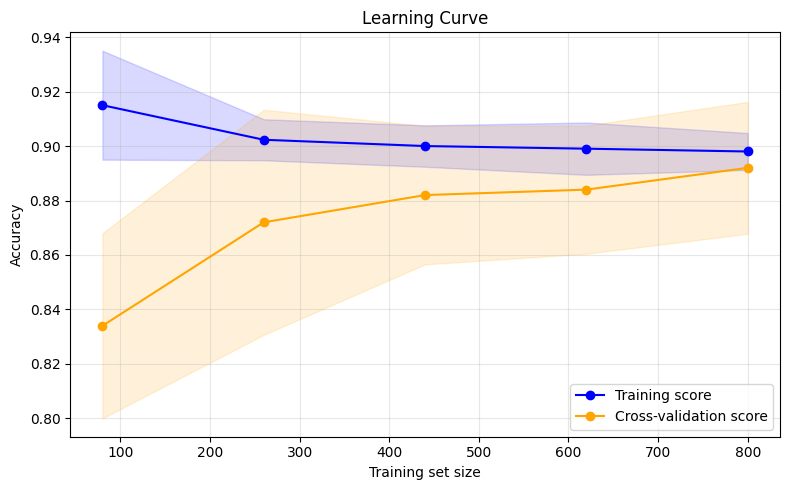

In [17]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000), X, y, cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=2024
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='blue')
plt.fill_between(train_sizes, test_mean - test_std,
                 test_mean + test_std, alpha=0.15, color='orange')
plt.plot(train_sizes, train_mean, 'o-',
         label='Training score', color='blue')
plt.plot(train_sizes, test_mean, 'o-',
         label='Cross-validation score', color='orange')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The learning curve reveals several important patterns about our logistic regression model.

**At small training sizes ($n = 80$):** The training accuracy is high ($0.915$) because the model can easily memorize a small dataset. But the cross-validation accuracy is significantly lower ($0.834$), creating a gap of $0.081$. This gap represents **overfitting** -- the model has learned patterns specific to the 80 training samples that do not generalize.

**As training size increases ($80 \to 800$):** The training accuracy *decreases* slightly (from $0.915$ to $0.898$) because it becomes harder to memorize a larger dataset. Simultaneously, the cross-validation accuracy *increases* steadily (from $0.834$ to $0.892$). The two curves converge, with the gap narrowing from $0.081$ to just $0.006$ at $n = 800$.

**Convergence behavior:** By $n = 800$, both curves have nearly flattened and converged at approximately $0.89-0.90$. This convergence tells us two things. First, the model is no longer significantly overfitting -- training and validation performance are nearly equal. Second, adding more data beyond $\sim 800$ samples is unlikely to yield substantial improvements. The model has reached its **capacity ceiling**: the accuracy logistic regression can achieve given these features.

**Diagnosis and next steps:** When both curves plateau at a level below our target accuracy, the bottleneck is **model complexity** (high bias), not data quantity. To improve further, we would need either more expressive features (feature engineering, polynomial terms) or a more powerful model (random forests, gradient boosting, neural networks). This is a textbook example of the **bias-dominated regime** -- more data will not help because the model has already extracted all the linear signal it can.

**Contrast with the overfitting regime:** If the curves had *not* converged -- i.e., a persistent gap between training ($\sim 0.98$) and validation ($\sim 0.85$) -- that would signal high variance (overfitting), and more data *would* help by regularizing the model through sheer volume.

### Validation Curves

A **validation curve** plots model performance as a function of a single hyperparameter, revealing the bias-variance tradeoff for that parameter. For logistic regression, the key hyperparameter is $C$ (inverse regularization strength).

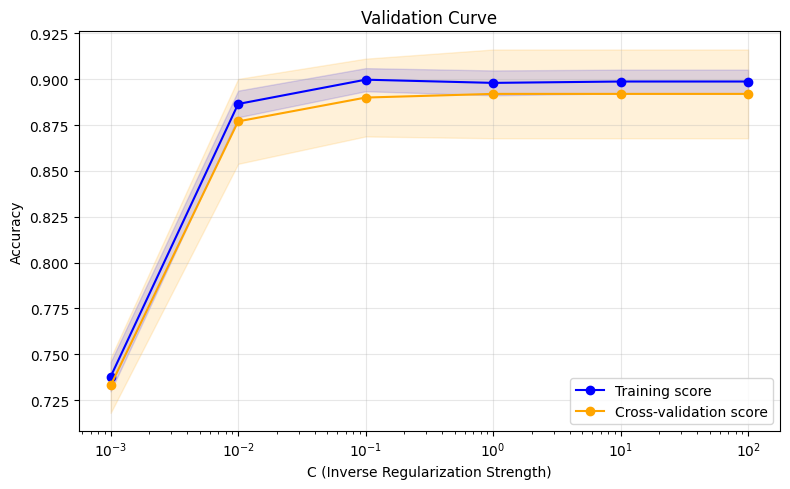

In [18]:
param_range = np.logspace(-3, 2, 6)

train_scores, test_scores = validation_curve(
    LogisticRegression(max_iter=1000), X, y, param_name="C",
    param_range=param_range, cv=5, scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.fill_between(param_range, train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='blue')
plt.fill_between(param_range, test_mean - test_std,
                 test_mean + test_std, alpha=0.15, color='orange')
plt.semilogx(param_range, train_mean, 'o-',
             label='Training score', color='blue')
plt.semilogx(param_range, test_mean, 'o-',
             label='Cross-validation score', color='orange')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The validation curve maps the bias-variance tradeoff across five orders of magnitude of the regularization parameter $C$.

**Strong regularization ($C = 0.001$):** Both training and CV accuracy are low ($0.738$ and $0.733$, respectively). The tiny gap between them ($0.005$) confirms that the model is not overfitting -- it is **underfitting**. The heavy penalty $\frac{1}{C} = 1000$ forces weights so close to zero that the model cannot capture even strong linear relationships. This is the **high-bias regime**.

**Moderate regularization ($C = 0.01$ to $C = 0.1$):** Performance improves dramatically. At $C = 0.01$, both curves jump to $\sim 0.88$. At $C = 0.1$, they reach $\sim 0.89-0.90$. The model now has enough flexibility to fit the genuine patterns in the data while the regularization still prevents overfitting to noise.

**Weak regularization ($C = 1$ to $C = 100$):** Both curves plateau at approximately $0.89-0.90$ with minimal further change. For this particular problem, relaxing regularization beyond $C = 0.1$ provides essentially no benefit. The logistic regression model has already captured all the linear signal available, and additional flexibility does not help (or hurt, since the problem is not prone to overfitting with $1{,}000$ samples and $20$ features).

**The key insight:** The validation curve confirms what the learning curve suggested -- this is a **capacity-limited** problem, not a regularization-sensitive one. Once we move past the clearly underfitting regime ($C < 0.01$), performance is remarkably stable across three orders of magnitude of $C$. In practice, this robustness to the hyperparameter is a desirable property: it means our model is not fragile and will perform consistently even if $C$ is not perfectly tuned.

**Connection to earlier sections:** The optimal $C \approx 0.1$ found here is consistent with the grid search result in Section 12.3 ($C = 0.1$, accuracy $= 0.918$) and Section 12.4 ($C = 0.1$, accuracy $= 0.894$ on the training subset). This cross-section consistency strengthens our confidence that $C = 0.1$ is a robust choice.

## Chapter Summary

This chapter developed a complete toolkit for rigorous model evaluation and selection. The key takeaways are:

**Cross-validation fundamentals:** A single train-test split gives an unreliable performance estimate. k-fold cross-validation averages over $k$ different splits, and **stratified k-fold** should be the default for classification tasks. We saw that stratification reduced the standard deviation of our accuracy estimates by $5.3\times$ (from $0.063$ to $0.012$) even on a balanced dataset.

**Advanced CV methods:** LOOCV provides nearly unbiased estimates but at high computational cost ($n$ model fits). **Nested cross-validation** prevents information leakage between hyperparameter tuning and model evaluation -- essential for honest performance reporting.

**Beyond accuracy:** For imbalanced datasets, accuracy alone is misleading. The `cross_validate` function lets us track precision, recall, and $F_1$ simultaneously. With $70/30$ imbalance, our model showed accuracy of $0.910$ but recall of only $0.820$ -- an $18\%$ miss rate on the minority class that accuracy alone would have obscured.

**Model selection:** Grid search is exhaustive but scales poorly. Randomized search with appropriate distributions (`loguniform` for regularization parameters) explores continuous spaces more efficiently and found $C = 0.1744$ compared to grid search's nearest candidate of $C = 0.1$.

**Diagnostic curves:** Learning curves diagnose whether the bottleneck is data quantity or model capacity. Validation curves reveal the bias-variance tradeoff for specific hyperparameters. Both are indispensable tools for making data-driven decisions about model development strategy.

The overarching principle: **never trust a single number**. Always examine performance across folds, across metrics, and across hyperparameter ranges. The goal is not just a model that works, but a model whose performance we understand and can defend to stakeholders.